In [72]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [73]:
import pandas as pd

data = pd.read_csv(r"E:\kaggle\heart.csv")

print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [74]:
# ==========================================
# Step 3: Dataset Information
# ==========================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [75]:
# ==========================================
# Step 6: Shape of Dataset
# ==========================================

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 1025
Columns : 14


In [76]:
# ==========================================
# Step 7: Missing Values
# ==========================================

print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [77]:
# ==========================================
# Step 8: Duplicate Values
# ==========================================

print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 723


In [78]:
# ==========================================
# Step 10: Feature Selection
# ==========================================

X = data[['age','sex']]

print(X.head())

   age  sex
0   52    1
1   53    1
2   70    1
3   61    1
4   62    0


In [79]:
X = data[['chol','age']]

print(X.head())

   chol  age
0   212   52
1   203   53
2   174   70
3   203   61
4   294   62


In [80]:
print(X.columns)

Index(['chol', 'age'], dtype='object')


In [81]:
X= data[['age','chol']]

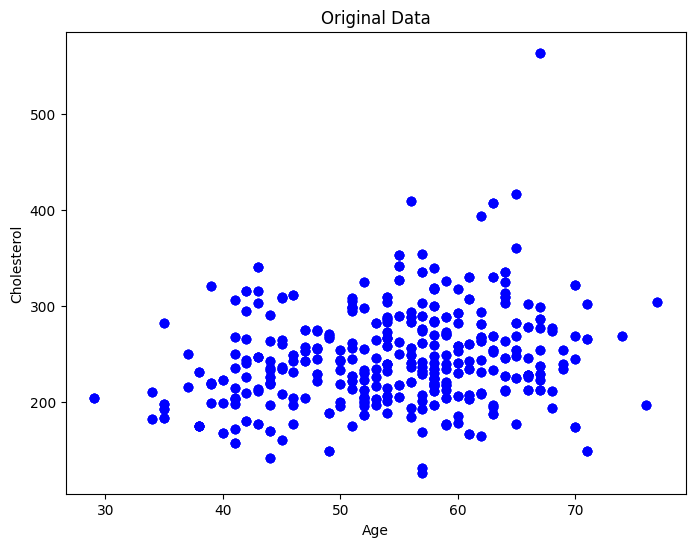

In [82]:
# ==========================================
# Step 11: Original Data Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X['age'],
    X['chol'],
    color='blue'
)

plt.title("Original Data")
plt.xlabel("Age")
plt.ylabel("Cholesterol")

plt.show()

In [83]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

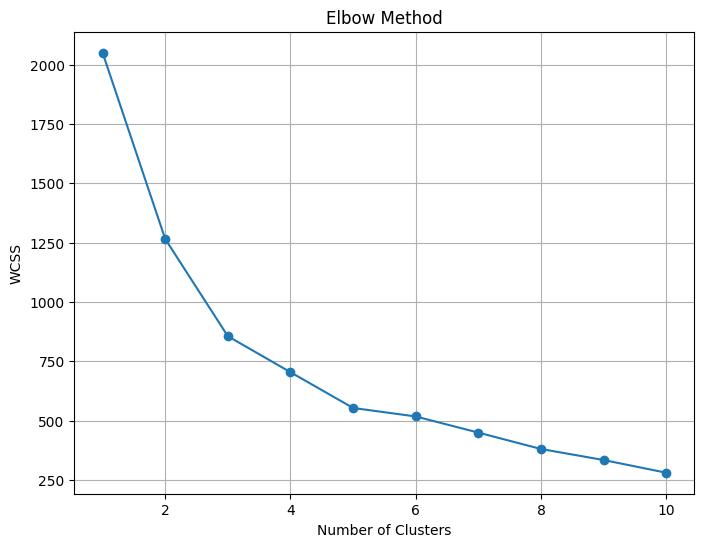

In [84]:
# ==========================================
# Step 13: Elbow Method
# ==========================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [85]:
# ==========================================
# Step 14: Train KMeans Model
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [86]:
# ==========================================
# Step 15: Add Cluster Column
# ==========================================

data["Cluster"] = clusters

print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  Cluster  
0   2     3       0        1  
1   0     3       0        1  
2   0     3       0        1  
3   1     3       0        1  
4   3     2       0        0  


In [87]:
# ==========================================
# Step 16: Cluster Centers
# ==========================================

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print(centers)

[[ 59.44863014 303.95547945]
 [ 59.51612903 218.05707196]
 [ 43.79090909 228.84242424]]


In [88]:
print(X.head())
print(X.columns)

   age  chol
0   52   212
1   53   203
2   70   174
3   61   203
4   62   294
Index(['age', 'chol'], dtype='object')


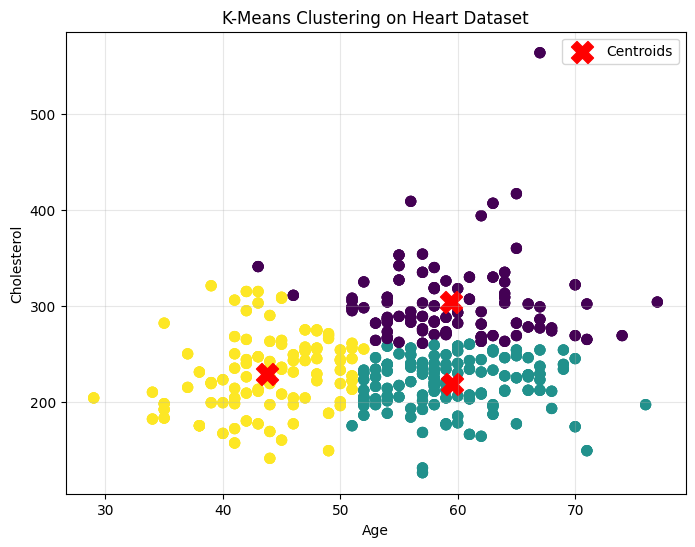

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(X['age'], X['chol'],
            c=kmeans.labels_,
            cmap='viridis',
            s=50)

plt.scatter(centers[:,0], centers[:,1],
            color='red',
            marker='X',
            s=250,
            label='Centroids')

plt.title("K-Means Clustering on Heart Dataset")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [90]:
# ==========================================
# Step 18: Cluster Counts
# ==========================================

print(data["Cluster"].value_counts())

Cluster
1    403
2    330
0    292
Name: count, dtype: int64


In [91]:
# ==========================================
# Step 19: Final Dataset
# ==========================================

data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Cluster
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,1
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,1
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,1
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0,1
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1,2


In [92]:
from sklearn.metrics import silhouette_score

In [93]:
# ==========================================
# Step 15: Calculate Silhouette Score
# ==========================================

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", round(score, 3))

Silhouette Score : 0.369


In [94]:
# ==========================================
# Find Best K using Silhouette Score
# ==========================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}  --->  Silhouette Score = {score:.3f}")

K = 2  --->  Silhouette Score = 0.356
K = 3  --->  Silhouette Score = 0.369
K = 4  --->  Silhouette Score = 0.340
K = 5  --->  Silhouette Score = 0.356
K = 6  --->  Silhouette Score = 0.314
K = 7  --->  Silhouette Score = 0.326
K = 8  --->  Silhouette Score = 0.329
K = 9  --->  Silhouette Score = 0.337
K = 10  --->  Silhouette Score = 0.355
